# statsmodels

# Закінчив на 4.2)

[Don't finish all](https://chatgpt.com/c/69997d4d-a418-8390-a5b6-aa58b022b9bd)

### 0) Підготовка даних і імпорти

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.stats.anova import anova_lm
from statsmodels.stats.weightstats import ttest_ind
from statsmodels.stats.diagnostic import het_arch

In [2]:
np.random.seed(13)
n = 400

x1 = np.random.normal(size=n)
x2 = np.random.normal(size=n)
group = np.random.choice(["A", "B", "C"], size=n, p=[0.35, 0.35, 0.30])

# справжня (невідома моделі) залежність
eps = np.random.normal(scale=1.0, size=n)
y = 2.0 + 1.5*x1 - 0.7*x2 + (group=="B")*0.8 + (group=="C")*(-0.5) + eps

df = pd.DataFrame({"y": y, "x1": x1, "x2": x2, "group": group})
df.head()

,y,x1,x2,group
0,0.760388,-0.712391,-0.191632,A
1,3.019434,0.753766,0.483829,C
2,-1.571784,-0.044503,1.275126,C
3,2.866275,0.451812,0.460995,A
4,4.236275,1.345102,-0.595686,C


### 1) OLS + довірчі інтервали + t-тести + F-тести + тестування гіпотез

#### 1.1 Лінійна регресія OLS (і формули як у R)

In [43]:
# R-style формула: y ~ x1 + x2 + C(group)
ols = smf.ols("y ~ x1 + x2 + C(group)", data=df).fit()

In [44]:
# print(ols.summary())

In [45]:
dff = pd.DataFrame({
    "income": [40, 45, 50, 60, 65, 70, 80, 90],
    "consumption": [38, 44, 46, 53, 57, 62, 68, 74]
})
model = smf.ols('consumption ~ income', data=dff)
result_ols = model.fit()

In [46]:
# print(results_dff.summary())

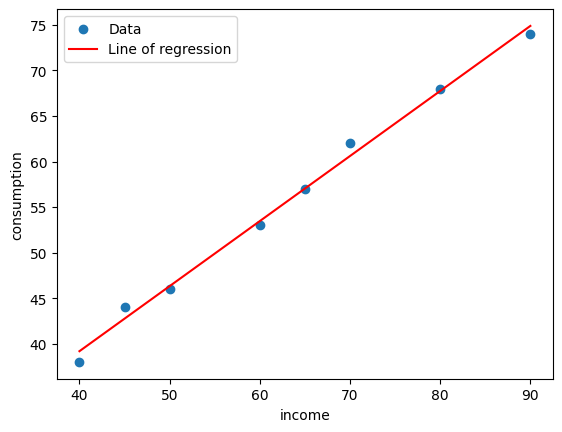

In [47]:
plt.scatter(dff['income'], dff['consumption'], label='Data')
plt.plot(dff['income'], result_ols.fittedvalues, color='red', label='Line of regression')
plt.xlabel('income')
plt.ylabel('consumption')
plt.legend()
plt.show()

#### 1.2 Довірчі інтервали

In [50]:
# Довірчі інтервали для коефіцієнтів (за замовчуванням 95%)
# ci_params = ols.conf_int()
ci_params = result_ols.conf_int()
ci_params.columns = ["CI_low", "CI_high"]
print(ci_params)

             CI_low    CI_high
Intercept  7.139124  14.075161
income     0.660573   0.767999


In [51]:
# Довірчі інтервали для середнього прогнозу / індивідуального прогнозу
new = df.sample(5, random_state=0)
pred = ols.get_prediction(new).summary_frame(alpha=0.05)
# pred = result_ols.get_prediction(new).summary_frame(alpha=0.05)
print(pred[["mean", "mean_ci_lower", "mean_ci_upper", "obs_ci_lower", "obs_ci_upper"]])

       mean  mean_ci_lower  mean_ci_upper  obs_ci_lower  obs_ci_upper
0  3.156486       2.981405       3.331567      1.230326      5.082646
1  5.418516       5.187719       5.649312      3.486495      7.350537
2  1.195216       1.008080       1.382353     -0.732077      3.122509
3  1.126101       0.932498       1.319704     -0.801831      3.054032
4  1.609713       1.383592       1.835833     -0.321755      3.541180


#### 1.3 t-тести для окремих коефіцієнтів

In [52]:
# t-test H0: bete_x1 = 1.5
print(ols.t_test("x1 = 1.5"))



                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0             1.4892      0.052     -0.208      0.836       1.387       1.591


In [53]:
# t-test H0: coeficient for x2 = 0
print(ols.t_test("x2 = 0"))

                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.7148      0.049    -14.481      0.000      -0.812      -0.618


#### 1.4 F-тести (спільні обмеження)

# F-test H0: (coeficient x1 = 0 ) and (coeficient x2 = 0  )
print(ols.f_test("x1 = 0, x2 = 0"))

In [55]:
# F-тест: усі ефекти групи = 0 (тобто C(group) не потрібна)
print(ols.f_test("C(group)[T.B] = 0, C(group)[T.C] = 0"))

<F test: F=60.84925156049582, p=9.195571297262018e-24, df_denom=395, df_num=2>


#### 1.5 Загальні лінійні гіпотези (Wald-тести)

In [56]:
# Wald: x1 - x2 = 0
print(ols.wald_test("x1 - x2 = 0"))

<F test: F=array([[1039.65538885]]), p=1.1044795350630205e-112, df_denom=395, df_num=1>


C:\Users\dimal\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


### 2) OLS, GLS, WLS, RLM (оцінювання параметрів і різні припущення)

#### 2.1 OLS (звичайні МНК)

In [57]:
ols = smf.ols("y ~ x1 + x2", data=df).fit()

#### 2.2 WLS (зважені МНК)

In [58]:
# приклад ваг: більша вага спостереженням з меншим "шумом"
# (в реальних задачах ваги треба обґрунтовувати)
w = 1.0 / (1.0 + df["x1"]**2)
wls = smf.wls("y ~ x1 + x2", data=df, weights=w).fit()
print(wls.summary())

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.579
Model:                            WLS   Adj. R-squared:                  0.577
Method:                 Least Squares   F-statistic:                     272.6
Date:                Sat, 21 Feb 2026   Prob (F-statistic):           3.10e-75
Time:                        13:03:16   Log-Likelihood:                -630.74
No. Observations:                 400   AIC:                             1267.
Df Residuals:                     397   BIC:                             1279.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.1897      0.056     39.056      0.0

#### 2.3 GLS (узагальнені МНК)

In [59]:
X = sm.add_constant(df[["x1", "x2"]])
y_vec = df["y"].values

# Демонстраційна sigma (наприклад, AR(1)-подібна кореляція по порядку рядків)
rho = 0.6
idx = np.arange(n)
sigma = rho ** np.abs(np.subtract.outer(idx, idx))

gls = sm.GLS(y_vec, X, sigma=sigma).fit()
print(gls.summary())

                            GLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.705
Model:                            GLS   Adj. R-squared:                  0.704
Method:                 Least Squares   F-statistic:                     475.4
Date:                Sat, 21 Feb 2026   Prob (F-statistic):          4.24e-106
Time:                        13:06:48   Log-Likelihood:                -660.60
No. Observations:                 400   AIC:                             1327.
Df Residuals:                     397   BIC:                             1339.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.1863      0.158     13.868      0.0

#### 2.4 RLM (робастна лінійна регресія)

In [60]:
rlm = smf.rlm("y ~ x1 + x2", data=df, M=sm.robust.norms.HuberT()).fit()
print(rlm.summary())

                    Robust linear Model Regression Results                    
Dep. Variable:                      y   No. Observations:                  400
Model:                            RLM   Df Residuals:                      397
Method:                          IRLS   Df Model:                            2
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Sat, 21 Feb 2026                                         
Time:                        13:07:27                                         
No. Iterations:                    12                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.1871      0.058     37.854      0.0

### 3) ANOVA (дисперсійний аналіз)

#### 3.1 Однофакторна / багатофакторна ANOVA через OLS + anova_lm

In [61]:
m = smf.ols("y ~ C(group)", data=df).fit()
print(anova_lm(m, typ=2))  # typ=2 або typ=3 (залежить від постановки)

               sum_sq     df          F    PR(>F)
C(group)    84.413182    2.0  11.656098  0.000012
Residual  1437.532299  397.0        NaN       NaN


In [63]:
m2 = smf.ols("y ~ C(group) + x1 + x2", data=df).fit()
print(anova_lm(m2, typ=2))

              sum_sq     df           F        PR(>F)
C(group)  115.852407    2.0   60.849252  9.195571e-24
x1        781.368613    1.0  820.797712  1.802892e-98
x2        199.631408    1.0  209.705126  2.015360e-38
Residual  376.025173  395.0         NaN           NaN


### 4) Логістична регресія і GLM (лінійні / “нелінійні” через лінк-функції)

### 4.1 Логістична регресія (binary)

In [64]:
lin = -0.3 + 1.2*df["x1"] - 0.8*df["x2"]
p = 1 / (1 + np.exp(-lin))
df["y_bin"] = (np.random.rand(n) < p).astype(int)

logit = smf.logit("y_bin ~ x1 + x2 + C(group)", data=df).fit(disp=False)
print(logit.summary())

# Odds ratios (exp(beta))
odds = np.exp(logit.params)
print(odds)

                           Logit Regression Results                           
Dep. Variable:                  y_bin   No. Observations:                  400
Model:                          Logit   Df Residuals:                      395
Method:                           MLE   Df Model:                            4
Date:                Sat, 21 Feb 2026   Pseudo R-squ.:                  0.2959
Time:                        13:09:34   Log-Likelihood:                -192.64
converged:                       True   LL-Null:                       -273.60
Covariance Type:            nonrobust   LLR p-value:                 5.677e-34
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -0.4948      0.206     -2.399      0.016      -0.899      -0.090
C(group)[T.B]     0.1288      0.297      0.433      0.665      -0.454       0.712
C(group)[T.C]     0.4237      0.315     